In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("cleaned_sales_dataset.csv")

In [3]:
print("First 5 Rows:")
print(df.head())


First 5 Rows:
   Customer_ID         Customer_Name  Gender       City     Category  \
0         1001  Timothy Castillo PhD    Male      Delhi    Groceries   
1         1002         Matthew Gomez  Female      Delhi  Electronics   
2         1003            Maria Dyer  Female  Bangalore  Electronics   
3         1004       Michael Roberts    Male    Chennai    Furniture   
4         1005        Laura Campbell    Male  Hyderabad    Furniture   

   Order_Date    Sales     Cost  Quantity  
0  2024-06-30  4273.06  2698.72         7  
1  2024-06-28  1992.19  1526.65         2  
2  2025-03-15  1219.42   902.75         7  
3  2025-12-21   946.03   680.98         8  
4  2024-06-10  1340.83   814.17         6  


In [4]:
print("\nDataset Info:")
print(df.info())



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Customer_ID    200 non-null    int64  
 1   Customer_Name  200 non-null    object 
 2   Gender         200 non-null    object 
 3   City           200 non-null    object 
 4   Category       200 non-null    object 
 5   Order_Date     200 non-null    object 
 6   Sales          200 non-null    float64
 7   Cost           200 non-null    float64
 8   Quantity       200 non-null    int64  
dtypes: float64(2), int64(2), object(5)
memory usage: 14.2+ KB
None


In [5]:
print("\nDescriptive Statistics:")
print(df.describe())


Descriptive Statistics:
       Customer_ID        Sales         Cost    Quantity
count   200.000000   200.000000   200.000000  200.000000
mean   1100.500000  2338.203250  1645.105450    5.605000
std      57.879185  1391.451041  1042.690666    2.739801
min    1001.000000   125.310000    68.960000    1.000000
25%    1050.750000  1126.927500   785.445000    3.000000
50%    1100.500000  2311.540000  1531.185000    6.000000
75%    1150.250000  3418.385000  2284.530000    8.000000
max    1200.000000  4987.970000  4316.100000   10.000000


In [6]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Customer_ID      0
Customer_Name    0
Gender           0
City             0
Category         0
Order_Date       0
Sales            0
Cost             0
Quantity         0
dtype: int64


In [7]:
df['Profit'] = df['Sales'] - df['Cost']


In [8]:
# 1. Total Sales by City
sales_city = df.groupby('City')['Sales'].sum().sort_values(ascending=False)
print("\nTotal Sales by City:")
print(sales_city)


Total Sales by City:
City
Bangalore    111037.96
Delhi        104717.30
Hyderabad     96460.93
Mumbai        87750.89
Chennai       67673.57
Name: Sales, dtype: float64


In [9]:
# 2. Total Sales by Category
sales_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\nTotal Sales by Category:")
print(sales_category)



Total Sales by Category:
Category
Clothing       114077.74
Electronics    103643.77
Sports          90217.73
Furniture       83936.62
Groceries       75764.79
Name: Sales, dtype: float64


In [10]:
# 3. Average Sales
avg_sales = df['Sales'].mean()
print("\nAverage Sales:", avg_sales)



Average Sales: 2338.20325


In [ ]:
qty_category = df.groupby('Category')['Quantity'].sum()
print("\nQuantity by Category:")
print(qty_category)


Quantity by Category:
Category
Clothing       253
Electronics    231
Furniture      209
Groceries      215
Sports         213
Name: Quantity, dtype: int64


In [12]:
# 5. Profit by Category
profit_category = df.groupby('Category')['Profit'].sum()
print("\nProfit by Category:")
print(profit_category)


Profit by Category:
Category
Clothing       32509.42
Electronics    30830.68
Furniture      25260.82
Groceries      20150.90
Sports         29867.74
Name: Profit, dtype: float64


In [13]:
correlation = df[['Sales','Cost','Quantity','Profit']].corr()

print("\nCorrelation Matrix:")
print(correlation)


Correlation Matrix:
             Sales      Cost  Quantity    Profit
Sales     1.000000  0.955032  0.117933  0.787965
Cost      0.955032  1.000000  0.115993  0.569969
Quantity  0.117933  0.115993  1.000000  0.085944
Profit    0.787965  0.569969  0.085944  1.000000


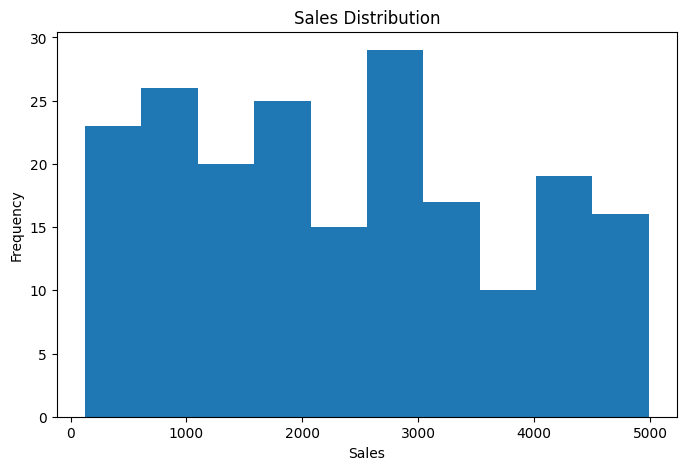

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=10)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()


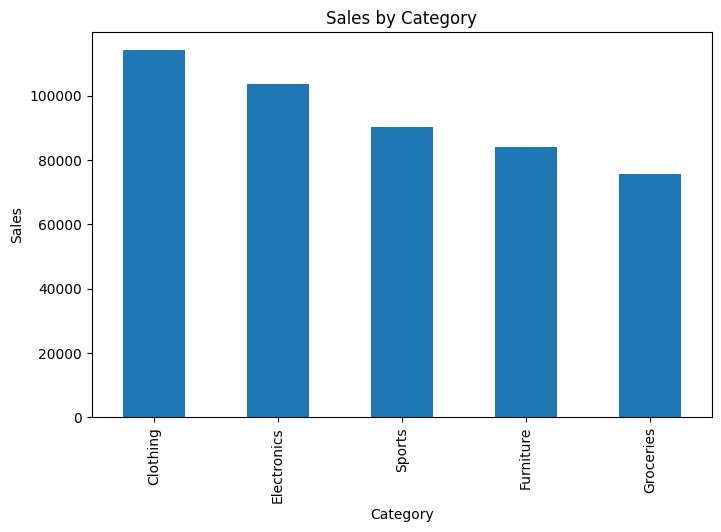

In [15]:
sales_category.plot(kind='bar', figsize=(8,5))
plt.title("Sales by Category")
plt.ylabel("Sales")
plt.show()


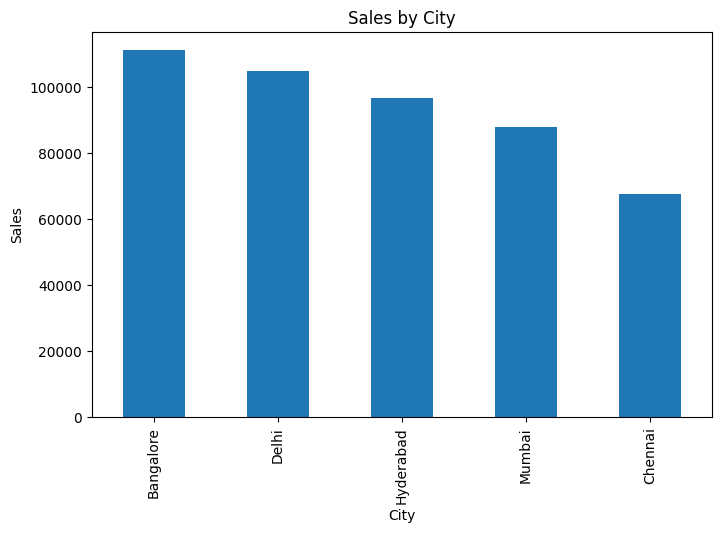

In [16]:
sales_city.plot(kind='bar', figsize=(8,5))
plt.title("Sales by City")
plt.ylabel("Sales")
plt.show()

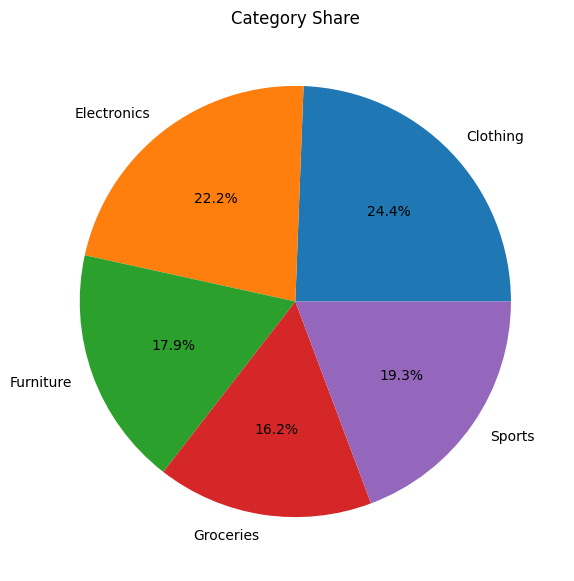

In [17]:
df.groupby('Category')['Sales'].sum().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,7)
)
plt.title("Category Share")
plt.ylabel("")
plt.show()


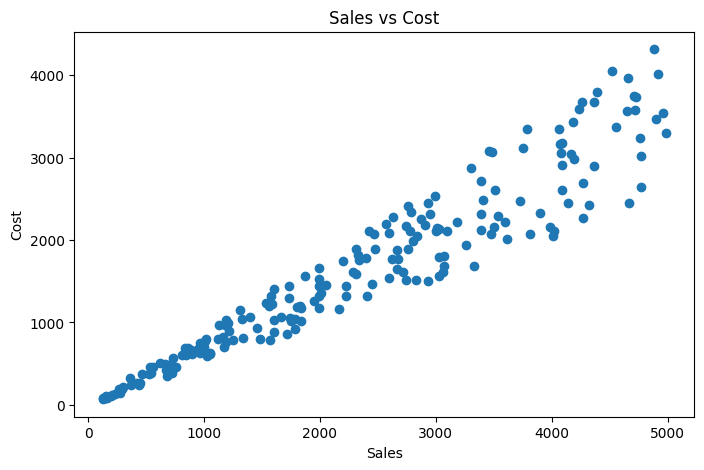

In [18]:
plt.figure(figsize=(8,5))
plt.scatter(df['Sales'], df['Cost'])
plt.title("Sales vs Cost")
plt.xlabel("Sales")
plt.ylabel("Cost")
plt.show()

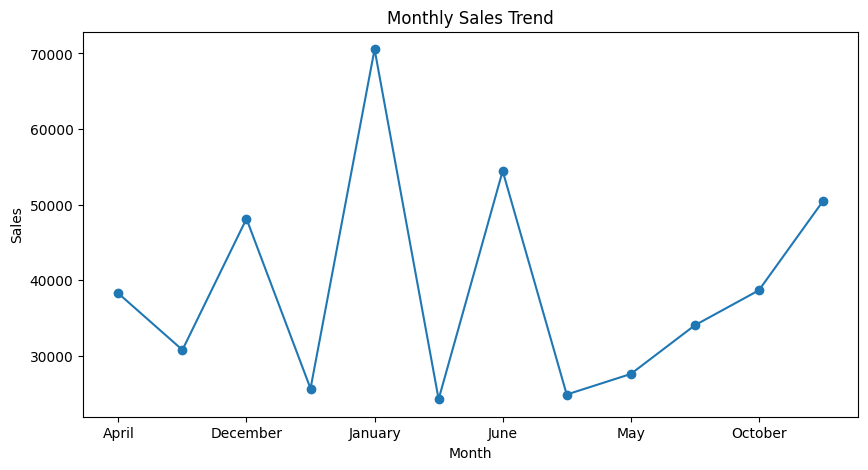

In [19]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

df['Month'] = df['Order_Date'].dt.month_name()

monthly_sales = df.groupby('Month')['Sales'].sum()

monthly_sales.plot(kind='line', marker='o', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

In [20]:
df.to_csv("EDA_Final_Dataset.csv", index=False)

print("\nEDA Completed Successfully!")


EDA Completed Successfully!
